Contents
1. Load and repair raw data
2. Data quality assessment
3. Data cleaning
4. Univariate analysis
5. Bivariate analysis (feature vs target)
6. Multivariate / correlation analysis
7. Summary of key insights

In [235]:
!pip install pandas numpy matplotlib seaborn
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import io  

1. Load and repair raw data

In [236]:
Path = "TeleCom_Data-1.csv"

with open(Path, encoding='utf-8') as file:
    lines = file.readlines()

fixed_lines = []
for line in lines:
    line = line.rstrip("\r\n")
    if line.startswith('"') and line.endswith('"'):
        line = line[1:-1]
    line = line.replace('""', '"')
    fixed_lines.append(line)

print(f"Number of lines in the file: {len(fixed_lines)}")
df = pd.read_csv(io.StringIO("\n".join(fixed_lines)),sep=";", quotechar='"', encoding='utf-8')
print(f"Data shape: {df.shape}")
df.head()





Number of lines in the file: 41181
Data shape: (41180, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [237]:
df.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

2. Data quality assessment

In [238]:
n_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")

Number of duplicate rows: 12


In [239]:
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
unkown_values = {}
for col in categorical_columns:
    unknown_count = (df[col] == 'unknown').sum()
    if(unknown_count > 0):
        unkown_values[col] = unknown_count

unknown_df = (pd.Series(unkown_values, name='Unknown Count').to_frame()
                .assign(Percentage=lambda x: (x['Unknown Count'] / len(df)) * 100)
                .sort_values(by='Percentage', ascending=False))
unknown_df            

,Unknown Count,Percentage
default,8596,20.874211
education,1731,4.203497
housing,990,2.404080
loan,990,2.404080
job,330,0.801360
marital,80,0.194269


In [240]:
pdays_999 = (df['pdays'] == 999).sum()
pdays_999_percentage = (pdays_999 / len(df)) * 100
print(f"Number of rows with pdays = 999: {pdays_999} ({pdays_999_percentage:.2f}%)")


Number of rows with pdays = 999: 39667 (96.33%)


In [241]:
over90_age = (df['age'] > 90).sum()
age_max = df['age'].max()
over90_age_percentage = (over90_age / len(df)) * 100
print(f"Number of rows with age > 90: {over90_age} ({over90_age_percentage:.2f}%). Max age: {age_max}")


duration_0 = (df['duration'] == 0).sum()
duration_0_percentage = (duration_0 / len(df)) * 100
print(f"Number of rows with duration = 0: {duration_0} ({duration_0_percentage:.2f}%)")



Number of rows with age > 90: 10 (0.02%). Max age: 98
Number of rows with duration = 0: 4 (0.01%)


In [242]:
target_variable = 'y'
print(df[target_variable].value_counts(normalize=True).round(2))

y
no     0.89
yes    0.11
Name: proportion, dtype: float64


3. Data cleaning
- Drop duplicate rows
- drop 10 rows with implausible age (>90)
- Create binary numeric Target column (y) (1: subscribed) 

In [243]:
cleaned_df = df.drop_duplicates().copy()
cleaned_df = cleaned_df[cleaned_df['age'] <= 90].copy()
cleaned_df["target"] = cleaned_df[target_variable].map({'yes': 1, 'no': 0})

cleaned_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,target
0,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


4. Univariate analysis

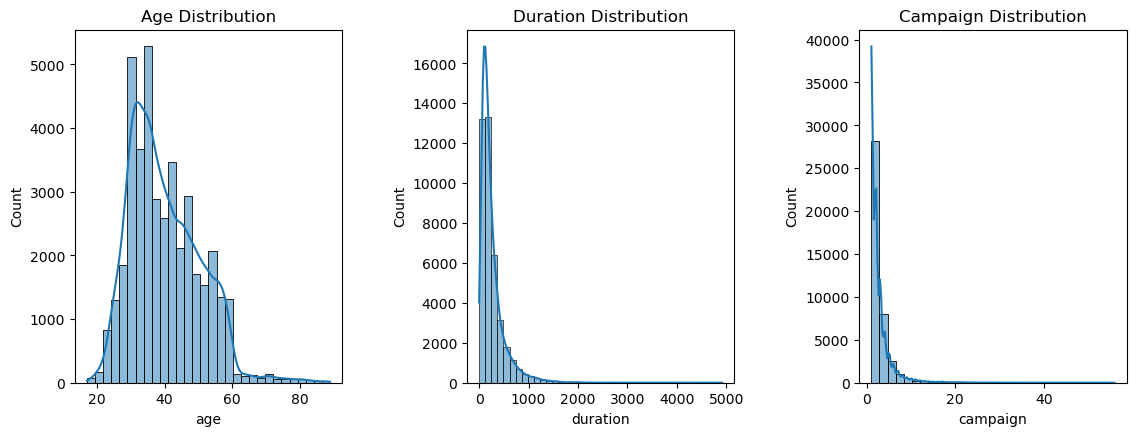

In [244]:
fig, axes =plt.subplots(1, 3, figsize=(12, 5))

axes[0].set_title('Age Distribution')
sns.histplot(cleaned_df['age'], bins=30, kde=True, ax=axes[0])

axes[1].set_title('Duration Distribution')
sns.histplot(cleaned_df['duration'], bins=40, kde=True, ax=axes[1])

axes[2].set_title('Campaign Distribution')
sns.histplot(cleaned_df['campaign'], bins=30, kde=True, ax=axes[2])

plt.tight_layout(pad=3.0)
plt.show()

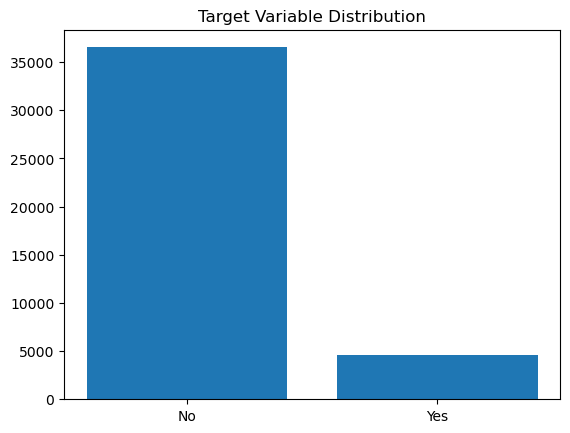

In [245]:
plt.bar(cleaned_df['target'].value_counts().index, cleaned_df['target'].value_counts().values)
plt.xticks([0, 1], ['No', 'Yes'])
plt.title('Target Variable Distribution')
plt.show()

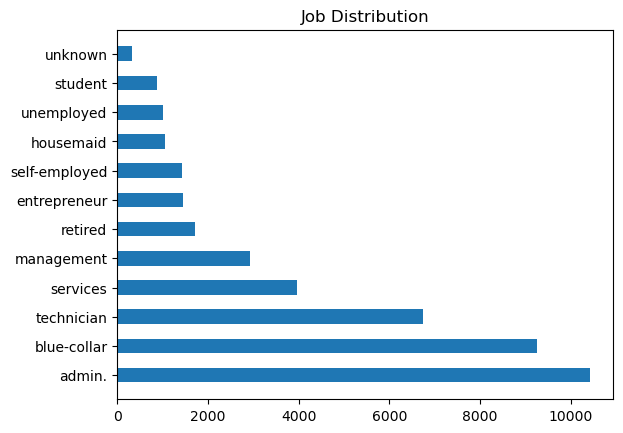

In [246]:
plt.barh(cleaned_df['job'].value_counts().index, cleaned_df['job'].value_counts().values,height=0.5)
plt.title('Job Distribution')
plt.show()

5. Bivariate analysis

In [247]:
def get_subcription_rate(col, df):
    subscription_rate = df.groupby(col)['target'].mean().sort_values(ascending=False) * 100
    return subscription_rate

In [248]:
def show_bar_subcription_rate(col, df, ax = None):
    if ax is not None:
        if df[col].nunique() <=5:
            ax.bar(get_subcription_rate(col, df).index, get_subcription_rate(col, df).values)
        else:
            ax.barh(get_subcription_rate(col, df).index, get_subcription_rate(col, df).values, height=0.5)
        ax.set_title(f'Subscription Rate by {col.capitalize()}')
        ax.set_xlabel('Subscription Rate (%)')
    else:
        if df[col].nunique() <=5:
            plt.bar(get_subcription_rate(col, df).index, get_subcription_rate(col, df).values)
        else:
            plt.barh(get_subcription_rate(col, df).index, get_subcription_rate(col, df).values, height=0.5)
        plt.title(f'Subscription Rate by {col.capitalize()}')
        plt.xlabel('Subscription Rate (%)')
        plt.show()

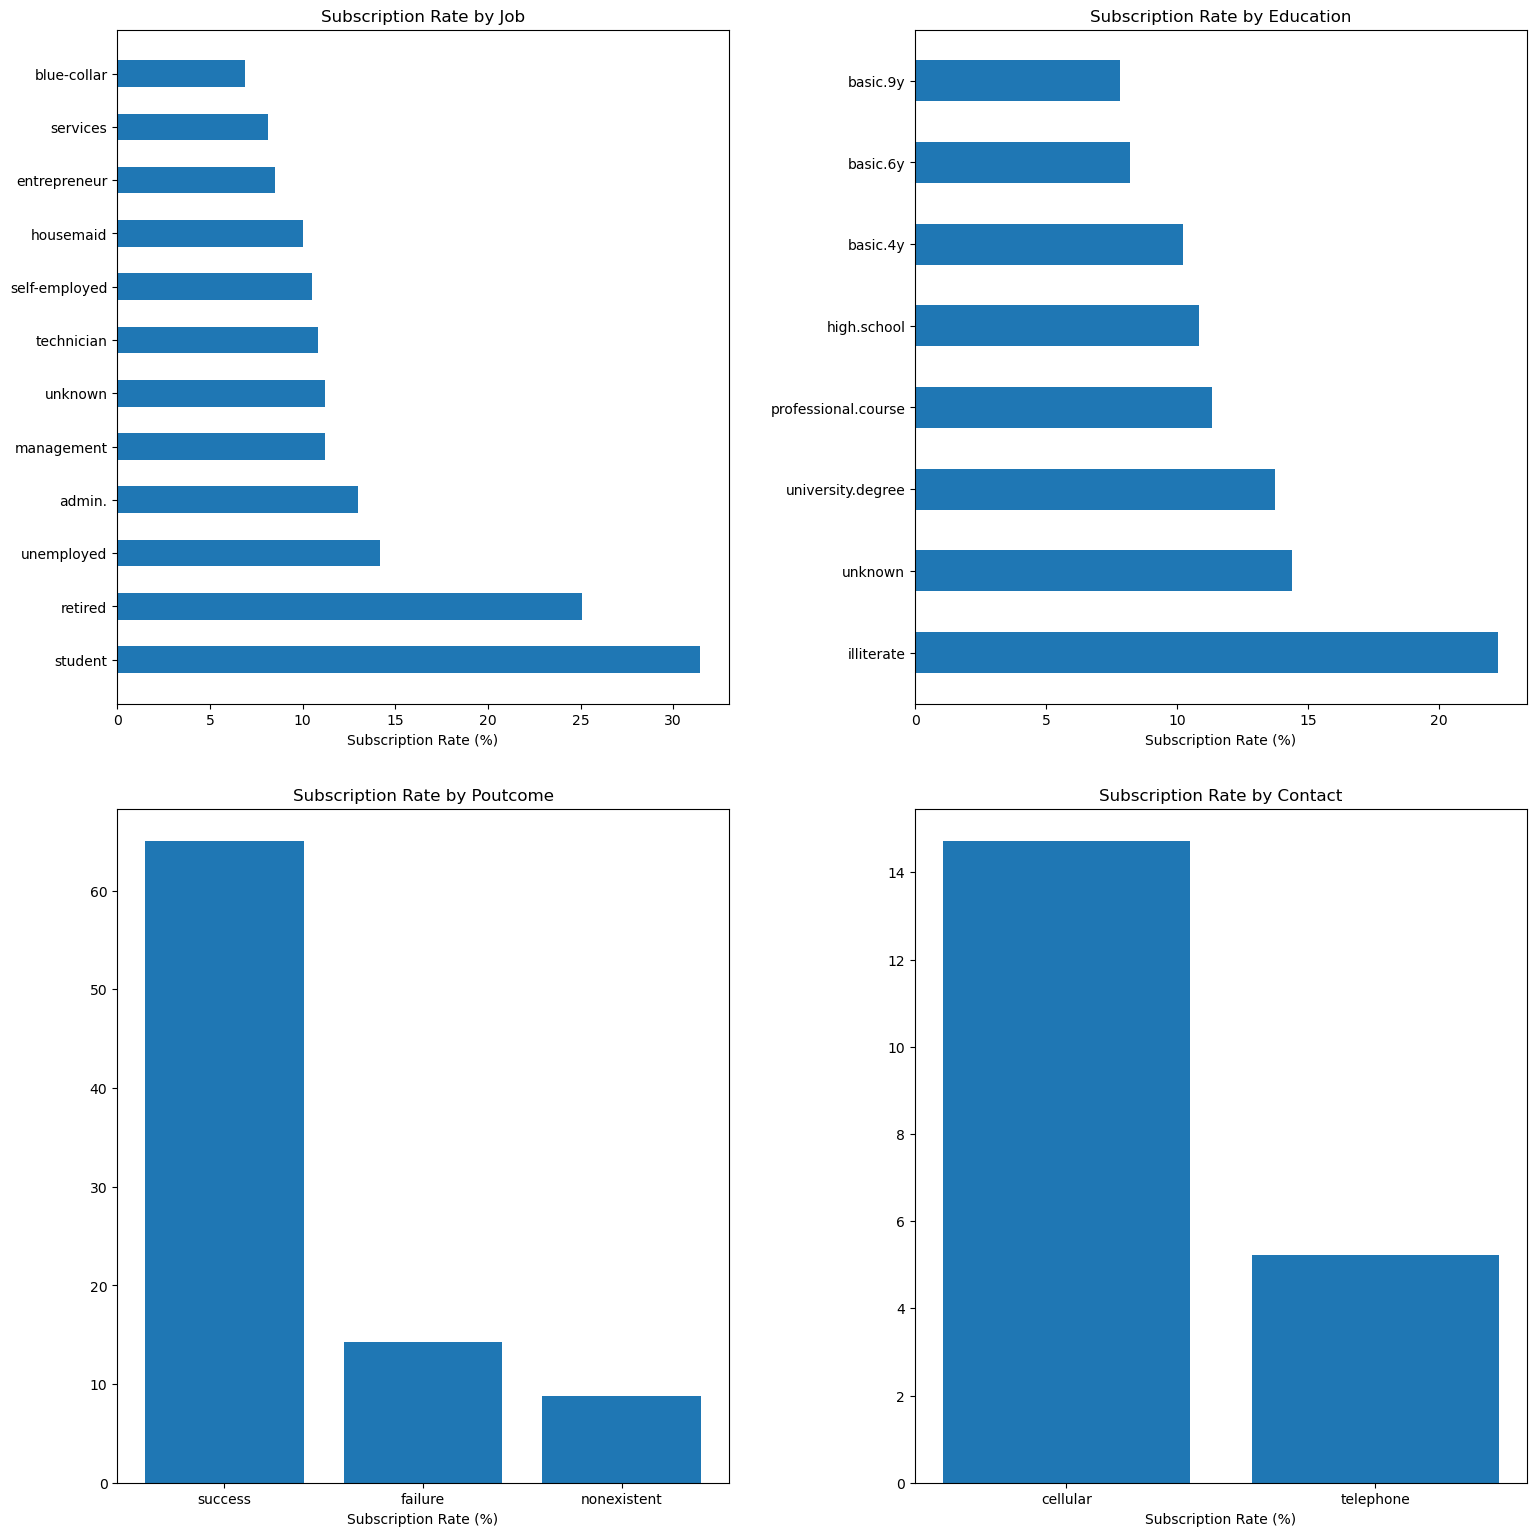

In [249]:
fig, ax = plt.subplots(2,2, figsize=(16, 16))
show_bar_subcription_rate('job', cleaned_df, ax[0, 0])
show_bar_subcription_rate('education', cleaned_df, ax[0, 1])
show_bar_subcription_rate('poutcome', cleaned_df, ax[1, 0])
show_bar_subcription_rate('contact', cleaned_df, ax[1, 1])
plt.tight_layout(pad=3.0)
plt.show()

<Axes: xlabel='age', ylabel='y'>

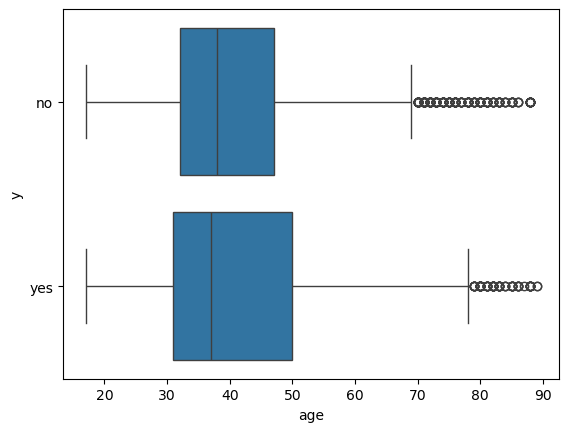

In [250]:
sns.boxplot(data=cleaned_df, x='age', y='y', )

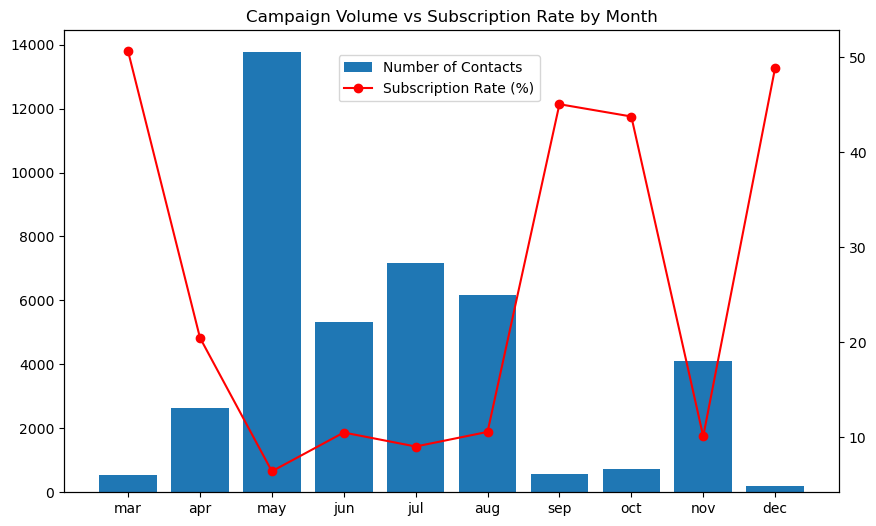

In [251]:
month = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']


fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(month, cleaned_df['month'].value_counts().reindex(month).values, label='Number of Contacts')
ax1 = ax.twinx()
ax1.plot(month, get_subcription_rate('month', cleaned_df).reindex(month).values, color='red', marker='o', label='Subscription Rate (%)')
fig.legend(loc="upper center", bbox_to_anchor=(0.5,0.85))
ax.set_title("Campaign Volume vs Subscription Rate by Month")

plt.show()

6. Multivariate / correlation analysis

Numerical columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'target']


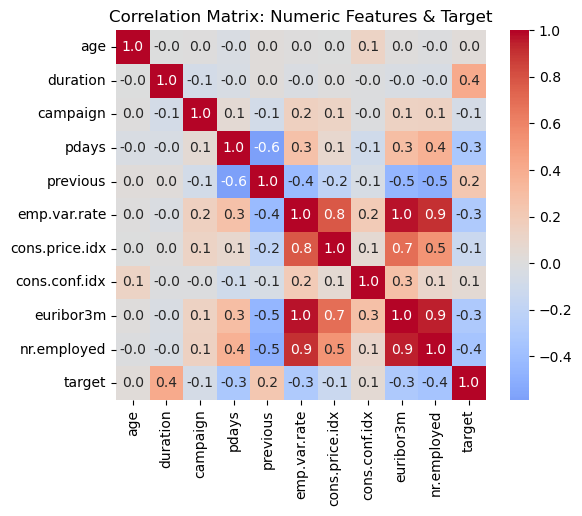

In [252]:
numerical_columns = cleaned_df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical columns:", numerical_columns)
correlation_matrix = cleaned_df[numerical_columns].corr()
sns.heatmap(correlation_matrix, annot=True, fmt="0.1f", cmap='coolwarm',center=0, square=True)
plt.title("Correlation Matrix: Numeric Features & Target")
plt.show()
